In [1]:
import matplotlib
matplotlib.rcParams['font.serif'] = ['Helvetica'] #+ matplotlib.rcParams['font.sans']
matplotlib.rcParams['font.size'] = 6
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams["ps.usedistiller"] = 'xpdf'
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.weight'] = 'normal'
matplotlib.rcParams["mathtext.fontset"] = 'cm'

In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import random
import math

import pandas as pd

import copy

import cvxpy
cp = cvxpy

import figurefirst as fifi

from braid_analysis import braid_analysis_plots
from braid_analysis import flymath
import fly_plot_lib.plot as fpl

import pynumdiff

import scipy.stats

In [3]:
import sys
from pathlib import Path


# Helper functions

In [4]:
from splitflow.affine_math_and_plot_helper import *

Using device: cpu


# Hyper parameters

In [5]:
RANDOMNESS = False

FIGURE_NAME = 'unifying_math_v4.svg'

# 
SPEED = 0.3

UPWIND_GAMMA_MULTIPLIER = 0.08

SACCADE_THRESHOLD_PROPORTIONAL = 8
SACCADE_THRESHOLD_DERIVATIVE = 3

SMOOTHING_WINDOW = 11

SLOPE_STD = 0.3

dt = 0.01

In [6]:
layout = fifi.svg_to_axes.FigureLayout(FIGURE_NAME, autogenlayers=True, make_mplfigures=True, hide_layers=[], dpi=600)
plt.close('all')

In [7]:
scenario = 'angled_laminar'

t, wind_direction, wind_speed = get_wind(scenario, RANDOMNESS, SMOOTHING_WINDOW, dt)
raw_circle_course = get_circle_basis(t, RANDOMNESS)
axis_ratio = get_axis_ratio(wind_direction, wind_speed)
color = get_color(scenario)

### Circle trajec and course

In [8]:
raw_circle_xy = get_circle_xy(raw_circle_course)
circle_x, circle_y = get_trajec(raw_circle_course, dt, SPEED)

In [9]:
ax = layout.axes[('circle_motif', 'circle_motif')]
ax.set_aspect('equal')
braid_analysis_plots.plot_arrowhead_trajectory(circle_x, circle_y, color='black', linewidth=0.75, ax=ax, arrow_length=0.03)
fifi.mpl_functions.adjust_spines(ax, [])
layout.append_figure_to_layer(layout.figures['circle_motif'], 'circle_motif', cleartarget=True)
layout.write_svg(FIGURE_NAME)

In [10]:
# ax = layout.axes[('affine', 'wind')]

# #####################################################################################################
# # Wind
# wind_direction_shifted = wrap_angle(wind_direction, midangle='pi')+np.pi
# ax.scatter(t, wind_direction_shifted, s=2, c='orange', linewidths=0, zorder=-1)
# ax.scatter(t, wind_direction_shifted-np.pi/2., s=0.5, c='orange', linewidths=0, zorder=-1)
# ax.set_ylim(0, 2*np.pi)

# xticks = [0, 1, 2, 3, 4, 5]
# xticklabels = np.array(xticks)
# ax.set_xlim(0, 5)
# ax.set_xticks(xticks)
# ax.set_xticklabels([])

# ax.set_yticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
# ax.set_yticklabels(['$0$', '', '', '', '$2\pi$'])

# fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'])

# ax.tick_params(axis='y', pad=2)
# ax.tick_params(axis='x', pad=2)

# fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'],
#                                  tick_length=2.5,
#                                  spine_locations={'left': 5, 'bottom': 5},
#                                  linewidth=0.5)
# fifi.mpl_functions.set_fontsize(ax, 6)

# ax.set_rasterization_zorder(0)

# Math

In [11]:
affine_warped_course_angle, affine_warped_circle_xy, mean_affine_warped_circle_xy = get_affine_warped_course_angle(axis_ratio, 
                                                                                                                   wind_direction, 
                                                                                                                   raw_circle_xy,
                                                                                                                   translation_magnitude=0
                                                                                                                   )

affine_trans_warped_course_angle, affine_trans_warped_circle_xy, mean_affine_trans_warped_circle_xy = get_affine_warped_course_angle(axis_ratio, 
                                                                                                                   wind_direction, 
                                                                                                                   raw_circle_xy,
                                                                                                                   translation_magnitude=0.5
                                                                                                                   )
circle_x, circle_y = get_trajec(affine_trans_warped_course_angle, dt, SPEED)

In [12]:
layout = fifi.svg_to_axes.FigureLayout(FIGURE_NAME, autogenlayers=True, make_mplfigures=True, hide_layers=[], dpi=600)
plt.close('all')

In [13]:
ax = layout.axes[('affine', 'course')]
plot_course(ax, t[0:-1:5], raw_circle_course[0:-1:5], None, affine_trans_warped_course_angle[0:-1:5], 
                show_labels=False,
            colors=['blue', 'magenta', 'magenta'],
                markersizes=[2,3,2],
                spines=['left',])

set_selective_rasterization(ax, 
                            rasterize_markers=['.'], 
                            rasterize_collections=[mcollections.PathCollection, 
                                                   mcollections.PolyCollection], 
                            raster_zorder=-1)
#ax.set_ylabel('Course ($\psi$)')
ax.set_yticklabels(['$-\pi$', '', '', '', '$\pi$'])
#ax.set_xlabel('Time')

[Text(0, -3.141592653589793, '$-\\pi$'),
 Text(0, -1.5707963267948966, ''),
 Text(0, 0.0, ''),
 Text(0, 1.5707963267948966, ''),
 Text(0, 3.141592653589793, '$\\pi$')]

In [14]:
ax = layout.axes[('affine', 'blue_ellipse')]
ax.set_aspect('equal')
ix_cross = np.where(np.abs(np.diff(raw_circle_course))>0.2)[0]
npoints_1_rotation = ix_cross[1] - ix_cross[0] + 1

ax.plot(raw_circle_xy[0,0:npoints_1_rotation:4], raw_circle_xy[1,0:npoints_1_rotation:4], '.', markersize=1, color='blue', linewidth=1, zorder=-1)
ax.set_ylim(-1.2, 1.2)
fifi.mpl_functions.adjust_spines(ax, [])
ax.set_rasterization_zorder(0)

In [15]:
if 1:
    ax = layout.axes[('affine', 'red_ellipse')]
else:
    fig = plt.figure(figsize=(3,3))
    ax = fig.add_subplot(111)

ix_cross = np.where(np.abs(np.diff(raw_circle_course))>0.2)[0]
npoints_1_rotation = ix_cross[1] - ix_cross[0] + 1

ax.set_aspect('equal')
ax.plot(raw_circle_xy[0,0:npoints_1_rotation], raw_circle_xy[1,0:npoints_1_rotation], '--', color='blue', linewidth=0.5, zorder=-3)
#ax.plot(affine_warped_circle_xy[0,0:npoints_1_rotation:4], affine_warped_circle_xy[1,0:npoints_1_rotation:4], '.', markersize=1, color='magenta', linewidth=1, zorder=-2)
color='magenta'
ax.plot(affine_trans_warped_circle_xy[0,0:npoints_1_rotation:4], affine_trans_warped_circle_xy[1,0:npoints_1_rotation:4], '.', markersize=1, color=color, linewidth=1, zorder=-1)

# draw some reference lines
rotation_angle = mean_angle(wind_direction) + np.pi #/2

c, s = np.cos(rotation_angle), np.sin(rotation_angle)
R = np.array([[c, -s], [s, c]])
S = np.array([[1, 0], [0, 1]])

AM = R@S

xs = np.linspace(0, 1, 10)
yline = np.vstack((xs*0, xs))
xline = np.vstack((xs, xs*0))

ax.plot(yline[0,:], yline[1,:], ':', color='black', linewidth=0.3, zorder=-10)
ax.plot(xline[0,:], xline[1,:], ':', color='black', linewidth=0.3, zorder=-10)

#ax.plot( (AM@yline)[0,:], (AM@yline)[1,:], ':', color='black', linewidth=0.3, zorder=-1)
#ax.plot( (AM@xline)[0,:], (AM@xline)[1,:], ':', color='black', linewidth=0.3, zorder=-1)

#ax.plot( , , '-', color='black', linewidth=0.6, zorder=-1)
x = 0.5*(AM@xline)[0,:]
y = 0.5*(AM@xline)[1,:]
braid_analysis_plots.plot_arrowhead_trajectory(x, y, color='black', linewidth=0.6, ax=ax, arrow_length=0.3)


ax.set_ylim(-1.2, 1.2)
fifi.mpl_functions.adjust_spines(ax, [])
ax.set_rasterization_zorder(0)

In [16]:
# if 1:
#     ax = layout.axes[('affine', 'magenta_ellipse')]
# else:
#     fig = plt.figure(figsize=(3,3))
#     ax = fig.add_subplot(111)

# ix_cross = np.where(np.abs(np.diff(raw_circle_course))>0.2)[0]
# npoints_1_rotation = ix_cross[1] - ix_cross[0] + 1

# ax.set_aspect('equal')
# ax.plot(raw_circle_xy[0,0:npoints_1_rotation], raw_circle_xy[1,0:npoints_1_rotation], '--', color='blue', linewidth=0.5, zorder=-3)
# ax.plot(affine_warped_circle_xy[0,0:npoints_1_rotation:4], affine_warped_circle_xy[1,0:npoints_1_rotation:4], '.', markersize=1, color='magenta', linewidth=1, zorder=-2)

# # draw some reference lines
# rotation_angle = mean_angle(wind_direction) + np.pi #/2

# c, s = np.cos(rotation_angle), np.sin(rotation_angle)
# R = np.array([[c, -s], [s, c]])
# S = np.array([[axis_ratio, 0], [0, 1]])

# AM = R@S

# xs = np.linspace(0, 1, 10)
# yline = np.vstack((xs*0, xs))
# xline = np.vstack((xs, xs*0))

# ax.plot(yline[0,:], yline[1,:], ':', color='black', linewidth=0.3, zorder=-10)
# ax.plot(xline[0,:], xline[1,:], ':', color='black', linewidth=0.3, zorder=-10)

# ax.plot( (AM@yline)[0,:], (AM@yline)[1,:], '-', color='black', linewidth=0.6, zorder=-1)
# ax.plot( (AM@xline)[0,:], (AM@xline)[1,:], '-', color='black', linewidth=0.6, zorder=-1)

# ax.set_ylim(-1.2, 1.2)
# fifi.mpl_functions.adjust_spines(ax, [])
# ax.set_rasterization_zorder(0)

In [17]:
# ax = layout.axes[('affine', 'trajec')]
# ax.set_aspect('equal')
# braid_analysis_plots.plot_arrowhead_trajectory(circle_x, circle_y, color='black', linewidth=0.76, ax=ax, arrow_length=0.06)
# fifi.mpl_functions.adjust_spines(ax, [])

In [18]:
# ax = layout.axes[('affine', 'affine_course')]
# plot_course(ax, t, raw_circle_course, affine_warped_course_angle, affine_trans_warped_course_angle, 
#             colors=['blue', 'magenta', color],
#             markersizes=[1,2,2],
#                 show_labels=False)
# set_selective_rasterization(ax, 
#                             rasterize_markers=['.'], 
#                             rasterize_collections=[mcollections.PathCollection, 
#                                                    mcollections.PolyCollection], 
#                             raster_zorder=-1)
# #ax.set_ylabel('Course ($\psi$)')
# ax.set_yticklabels(['$-\pi$', '', '', '', '$\pi$'])
# #ax.set_xlabel('Time')

In [19]:
# set_selective_rasterization(ax, 
#                             rasterize_markers=['.'], 
#                             rasterize_collections=[mcollections.PathCollection, 
#                                                    mcollections.PolyCollection], 
#                             raster_zorder=-1)

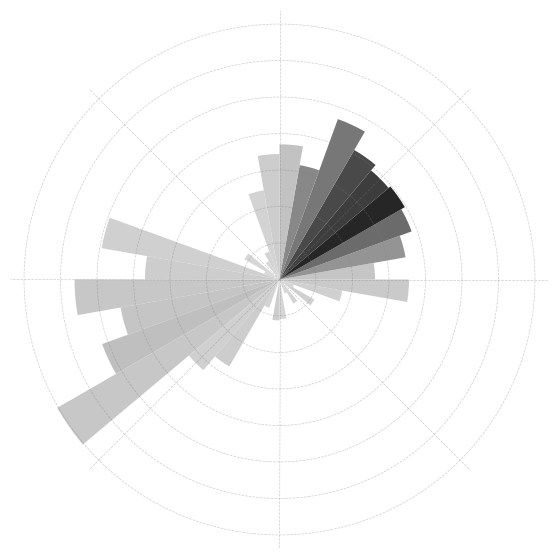

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from typing import List, Optional, Tuple


def circular_distribution_plot(
    directions: List[float],
    magnitudes: List[float],
    ax: Optional[plt.Axes] = None,
    bins: int = 36,
    radial_limit: Optional[float] = None,
    log_scale: bool = False,
    normalize: bool = False,
    figsize: Tuple[int, int] = (7, 7),
) -> plt.Axes:
    """
    Create a circular distribution (polar) plot for vector directions and magnitudes.

    Bar height encodes mean magnitude per bin. Bar darkness encodes count density
    (how many vectors fall in that bin), mapped from light gray (few) to black (many).
    Together these show both the strength and prevalence of vectors in each direction.

    Parameters
    ----------
    directions   : Sequence of direction angles in radians (-pi to pi).
    magnitudes   : Corresponding magnitudes for each direction vector.
    ax           : Existing polar Axes to draw into. If None, a new figure is created.
    bins         : Number of angular bins around the circle (default 36 -> 10 deg each).
    radial_limit : Upper limit of the radial axis. Applied after any transforms.
    log_scale    : If True, apply log1p transform to mean magnitudes before plotting.
    normalize    : If True, normalize mean magnitudes to sum to 1 across bins.
                   Useful for comparing distributions with different overall scales.
    figsize      : Figure size in inches, used only when ax is None.

    Returns
    -------
    ax           : The polar Axes object.

    Example
    -------
    >>> import numpy as np
    >>> rng = np.random.default_rng(42)
    >>> dirs = rng.uniform(-np.pi, np.pi, 200)
    >>> mags = rng.rayleigh(scale=5, size=200)
    >>> ax = circular_distribution_plot(dirs, mags)
    """
    directions = np.asarray(directions, dtype=float)
    magnitudes = np.asarray(magnitudes, dtype=float)

    if directions.shape != magnitudes.shape:
        raise ValueError("directions and magnitudes must have the same length.")

    # --- Binning ---
    radians = directions % (2 * np.pi)
    bin_edges = np.linspace(0, 2 * np.pi, bins + 1)
    bin_width = bin_edges[1] - bin_edges[0]

    bin_indices = np.clip(np.digitize(radians, bin_edges) - 1, 0, bins - 1)

    bin_total_mag = np.zeros(bins)
    bin_counts = np.zeros(bins, dtype=float)
    for idx, mag in zip(bin_indices, magnitudes):
        bin_total_mag[idx] += mag
        bin_counts[idx] += 1

    # Mean magnitude per bin (bar height); empty bins stay at 0
    bin_mean_mag = np.where(bin_counts > 0, bin_total_mag / bin_counts, 0.0)

    # --- Transforms ---
    if normalize and bin_mean_mag.sum() > 0:
        bin_mean_mag = bin_mean_mag / bin_mean_mag.sum()

    if log_scale:
        bin_mean_mag = np.log1p(bin_mean_mag)

    # --- Bar colours: count density mapped to gray (light = few, dark = many) ---
    count_norm = Normalize(vmin=0, vmax=bin_counts.max() if bin_counts.max() > 0 else 1)
    # Map normalised count to a gray value: 0 -> 0.85 (light), 1 -> 0.15 (dark)
    gray_values = 0.85 - 0.70 * count_norm(bin_counts)
    bar_colors = [(g, g, g, 1.0) for g in gray_values]

    # --- Axes ---
    if ax is None:
        _, ax = plt.subplots(figsize=figsize, subplot_kw={"projection": "polar"})

    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)

    # --- Bars ---
    bars = ax.bar(
        bin_edges[:-1],
        bin_mean_mag,
        width=bin_width,
        color=bar_colors,
        edgecolor="none",
        linewidth=0.4,
        align="edge",
    )

    # --- Clean up labels and ticks ---
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(color="grey", linestyle="--", linewidth=0.5, alpha=0.4)

    if radial_limit is not None:
        ax.set_ylim(0, radial_limit)

    ax.spines["polar"].set_visible(False)

    return ax


# ---------------------------------------------------------------------------
# Quick demo
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    rng = np.random.default_rng(0)

    # Cluster 1: many vectors, high magnitude (NE)
    # Cluster 2: few vectors, low magnitude (SW)
    # Background: sparse uniform noise
    dirs = np.concatenate([
        rng.normal(loc=np.pi/4,  scale=0.35, size=300),
        rng.normal(loc=-2.8,     scale=0.5,  size=30),
        rng.uniform(-np.pi, np.pi,           size=50),
    ])
    mags = np.concatenate([
        rng.rayleigh(scale=8,  size=300),
        rng.rayleigh(scale=12, size=30),
        rng.rayleigh(scale=2,  size=50),
    ])

    ax = circular_distribution_plot(dirs, mags)
    plt.show()

In [21]:
ax = layout.axes[('wind', 'wind')]
    
circular_distribution_plot(wind_direction,
                           wind_speed,
                                ax = ax,
                                bins = 50,
                                normalize=True,
                                radial_limit=0.1
                            )

{'axis': <PolarAxes: label='wind'>, 'figname': 'wind'}

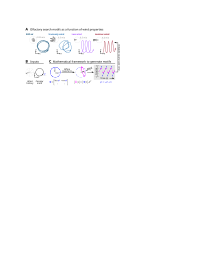

In [22]:
layout.append_figure_to_layer(layout.figures['wind'], 'wind', cleartarget=True)
layout.append_figure_to_layer(layout.figures['affine'], 'affine', cleartarget=True)
layout.write_svg(FIGURE_NAME)
from IPython.display import display,SVG
display(SVG(FIGURE_NAME))